# CliffWalking Random Baseline

## 实验目标

这个 notebook 不训练任何策略，也不使用强化学习算法。它的目标是先展示在 CliffWalking 环境里完全随机选择动作时，智能体通常会有多容易掉下悬崖。这个 baseline 是后续 `SARSA` notebook 的参照系，用来帮助读者先建立一个最直观的风险感受。

## 环境背景

CliffWalking 是一个经典的网格世界风险控制任务。智能体需要从起点走到终点，但起点和终点之间紧贴着一整段悬崖区域。只要一步踩空，就会立刻掉下悬崖并受到巨大惩罚，然后被重置回起点。这个环境非常适合用来解释为什么有些强化学习算法会学出更保守的行为模式。

## 方法说明

这里的方法就是纯随机动作采样：每一步直接调用 `env.action_space.sample()` 选择动作，不维护价值函数，也不更新策略。它不是正式算法，但它能非常直观地说明这个环境为什么不能依赖随机行为解决。

## 设备与并行说明

- 本实验默认使用 `CPU`
- 不使用 `CUDA` 或 `MPS`
- 不启用并行环境

原因是这个 notebook 主要做的是环境交互统计，不涉及神经网络训练。

In [1]:
from pathlib import Path

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

In [2]:
ENV_ID = "CliffWalking-v1"
NUM_EPISODES = 5000
MAX_STEPS = 200
SEED = 42

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

env = gym.make(ENV_ID)

## 参数选择说明

- `NUM_EPISODES = 5000`：让随机策略的统计结果更稳定
- `MAX_STEPS = 200`：给足够步数观察随机游走、掉崖和偶然到达终点的情况

这里的重点不是训练效率，而是建立一个清晰的风险基线。

In [3]:
episode_rewards = []
episode_lengths = []
successes = []
cliff_falls = []

for episode in tqdm(range(NUM_EPISODES), desc="Random episodes"):
    state, info = env.reset(seed=SEED + episode)
    total_reward = 0.0
    fell = 0

    for step in range(MAX_STEPS):
        action = env.action_space.sample()
        next_state, reward, terminated, truncated, info = env.step(action)
        total_reward += reward

        if reward <= -100:
            fell = 1

        state = next_state

        if terminated or truncated:
            episode_lengths.append(step + 1)
            successes.append(int(terminated))
            break
    else:
        episode_lengths.append(MAX_STEPS)
        successes.append(0)

    episode_rewards.append(total_reward)
    cliff_falls.append(fell)

env.close()

Random episodes:   0%|          | 0/5000 [00:00<?, ?it/s]

In [4]:
summary = pd.DataFrame(
    {
        "reward": episode_rewards,
        "episode_length": episode_lengths,
        "success": successes,
        "cliff_fall": cliff_falls,
    }
)
summary.describe(include="all")

,reward,episode_length,success,cliff_fall
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,-2100.879000,198.693000,0.019800,0.998800
std,672.791243,10.950303,0.139326,0.034624
min,-5150.000000,27.000000,0.000000,0.000000
25%,-2576.000000,200.000000,0.000000,1.000000
50%,-2081.000000,200.000000,0.000000,1.000000
75%,-1586.000000,200.000000,0.000000,1.000000
max,-27.000000,200.000000,1.000000,1.000000


In [5]:
success_rate = float(np.mean(successes))
avg_reward = float(np.mean(episode_rewards))
avg_length = float(np.mean(episode_lengths))
fall_rate = float(np.mean(cliff_falls))

metrics = pd.DataFrame(
    {
        "metric": ["success_rate", "average_reward", "average_episode_length", "cliff_fall_rate"],
        "value": [success_rate, avg_reward, avg_length, fall_rate],
    }
)
metrics

,metric,value
0,success_rate,0.0198
1,average_reward,-2100.8790
2,average_episode_length,198.6930
3,cliff_fall_rate,0.9988


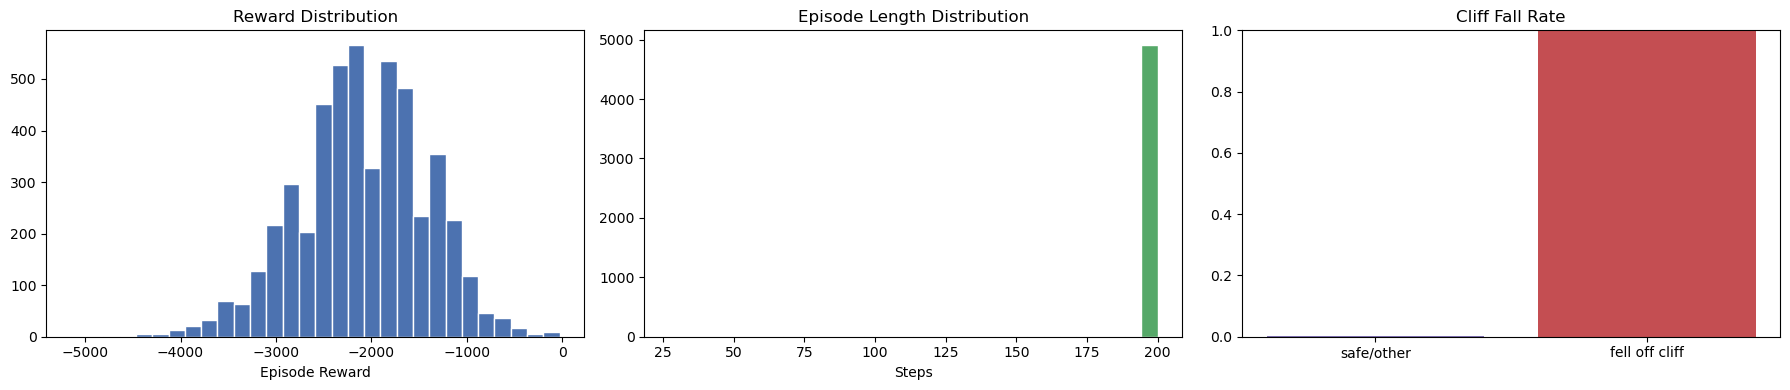

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(episode_rewards, bins=30, color="#4c72b0", edgecolor="white")
axes[0].set_title("Reward Distribution")
axes[0].set_xlabel("Episode Reward")

axes[1].hist(episode_lengths, bins=30, color="#55a868", edgecolor="white")
axes[1].set_title("Episode Length Distribution")
axes[1].set_xlabel("Steps")

axes[2].bar(["safe/other", "fell off cliff"], [1 - fall_rate, fall_rate], color=["#8172b3", "#c44e52"])
axes[2].set_title("Cliff Fall Rate")
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "random_baseline_overview.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
metrics.to_csv(RESULTS_DIR / "random_baseline_metrics.csv", index=False)
summary.to_csv(RESULTS_DIR / "random_baseline_episode_summary.csv", index=False)

print(f"Success rate: {success_rate:.4f}")
print(f"Average reward: {avg_reward:.2f}")
print(f"Average episode length: {avg_length:.2f}")
print(f"Cliff fall rate: {fall_rate:.4f}")
print(f"Saved results to: {RESULTS_DIR.resolve()}")

Success rate: 0.0198
Average reward: -2100.88
Average episode length: 198.69
Cliff fall rate: 0.9988
Saved results to: /Users/bizi/Desktop/GitHub/openai-gym-reinforcement-learning-lab/experiments/03-cliffwalking-sarsa/results


## 结果解读

随机策略在 CliffWalking 里通常会频繁掉下悬崖，平均回报很差。这说明这个环境的核心挑战不是简单到达终点，而是在带有巨大风险惩罚的区域里学会更稳妥的路径选择。